In [12]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


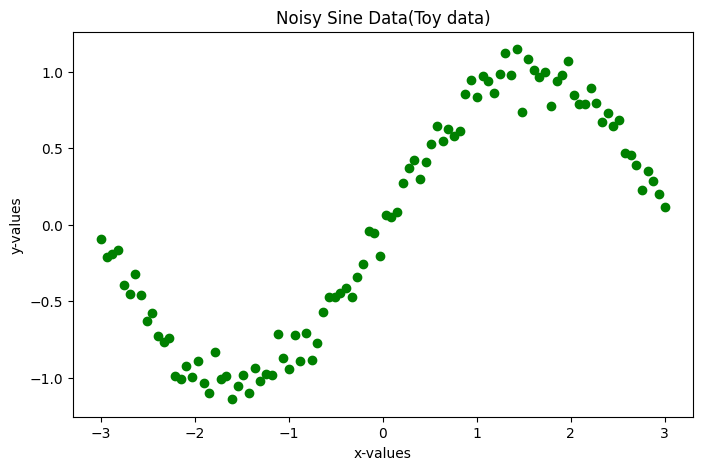

Initial weight: -0.014153707420504143
Initial bias: -0.00420645322765359


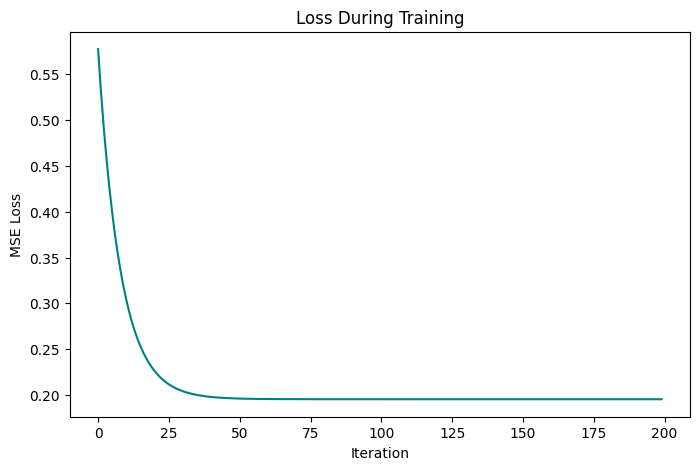

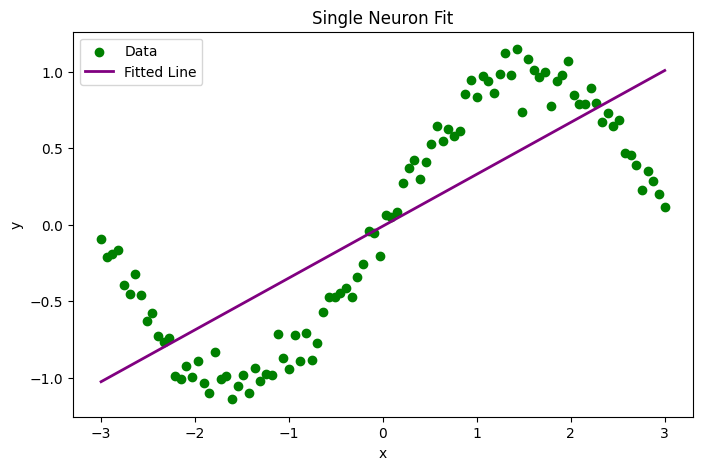

In [13]:
# TODO: Generate the toy data
x = np.linspace(-3, 3, 100)
y = np.sin(x)

# add some noise
noise = np.random.normal(0, 0.1, size=x.shape)
y = y + noise

#   Plot it.
plt.figure(figsize=(8,5))
plt.scatter(x, y, color="green")
plt.title("Noisy Sine Data(Toy data)")
plt.xlabel("x-values")
plt.ylabel("y-values")
plt.show()

# TODO: Initialise w and b to small random values.
# multiply by 0.01 to get small values
w = np.random.randn() * 0.01
b = np.random.randn() * 0.01

print("Initial weight:", w)
print("Initial bias:", b)

# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:
lr = 0.01
epochs = 200

loss_history = []

for epoch in range(epochs):
  # Forward pass
  y_hat = w * x + b

  # Compute loss
  loss = np.mean((y_hat - y) ** 2)

  # Compute gradients
  dw = np.mean(2 * (y_hat - y) * x)
  db = np.mean(2 * (y_hat - y))

  # Update parameters
  w -= lr * dw
  b -= lr * db

  # Record the loss at every step
  loss_history.append(loss)

# TODO: Plot (a) the loss curve over the 200 steps, and
#             (b) the data with the fitted line on top.

# (a) the loss curve over the 200 steps, and
plt.figure(figsize=(8,5))
plt.plot(loss_history, color="teal")
plt.title("Loss During Training")
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.show()

# (b) the data with the fitted line on top.
plt.figure(figsize=(8,5))
plt.scatter(x, y, label="Data", color="green")
plt.plot(x, w * x + b, color="purple", linewidth=2, label="Fitted Line")
plt.title("Single Neuron Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

### Student Reasoning — The single neuron

**1. Derive dLoss/dw on paper and include a photo or the LaTeX in this cell — does it match the code?**

![Derivative](derivative.png)

This matches the implementation in the code:

```python
dw = np.mean(2 * (y_hat - y) * x)
```

because `np.mean(...)` computes the average, which is equivalent to

$$
\frac{1}{n}\sum.
$$


**2. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting, and WHY can a single neuron never fit a sine wave, no matter how long you train?**

The model is **underfitting**, not overfitting.

A single neuron can only learn a **linear relationship**, since its prediction is

$$
\hat{y}=wx+b,
$$

which represents a straight line. However, the target function

$$
y=\sin(x)
$$

is **non-linear** and continuously curves up and down. No matter how long the model is trained, adjusting only the weight \(w\) and bias \(b\) can only change the slope and position of the line. It cannot produce the curved shape of a sine wave.

As a result, the loss decreases at first because the model finds the best possible straight line, but it eventually stops improving because the model has reached the limit of its capacity. This is an example of **underfitting**, where the model is too simple to capture the underlying pattern in the data.

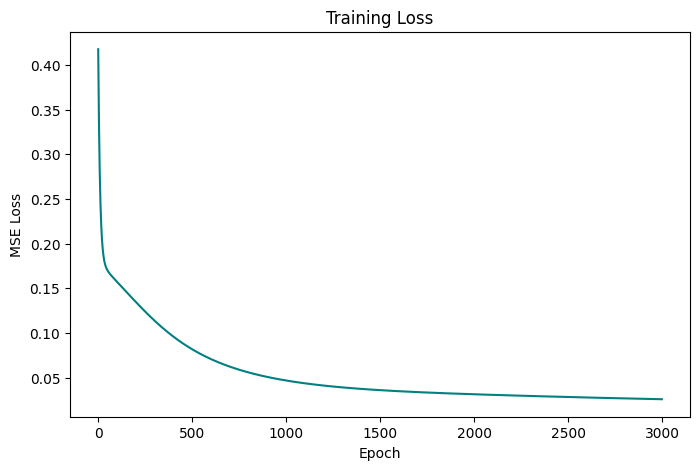

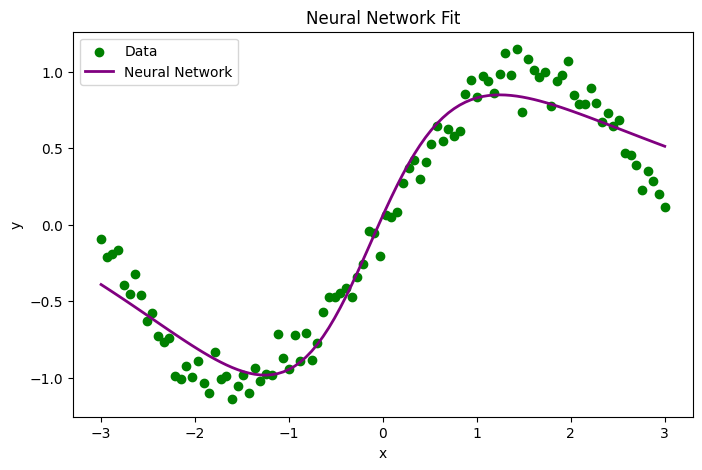

In [16]:
# TODO: Initialise parameters
#   W1: shape (1, 8),  b1: shape (8,)
#   W2: shape (8, 1),  b2: shape (1,)

# Make x and y column vectors
x = x.reshape(-1, 1)
y = y.reshape(-1, 1)

#   Small random values (e.g. np.random.randn(...) * 0.5)

# Hidden layer parameters
W1 = np.random.randn(1, 8) * 0.5
b1 = np.random.randn(8) * 0.5

# Output layer parameters
W2 = np.random.randn(8, 1) * 0.5
b2 = np.random.randn(1) * 0.5

# TODO: Forward pass (keep the intermediate values — you need them for backprop):
z1 = x @ W1 + b1 # pre-activation, shape (100, 8)
h  = np.tanh(z1) # activation
y_hat = h @ W2 + b2 # output, shape (100, 1)
loss  = np.mean((y_hat - y) ** 2)

# TODO: Backward pass (the chain rule, layer by layer):
d_yhat = 2 * (y_hat - y) / len(y)
dW2 = h.T @ d_yhat ;  db2 = d_yhat.sum(axis=0)
dh  = d_yhat @ W2.T
dz1 = dh * (1 - np.tanh(z1) ** 2)     # derivative of tanh
dW1 = x.T @ dz1 ;  db1 = dz1.sum(axis=0)

# TODO: Update all parameters with learning rate lr, loop for ~3000 steps,
#   record the loss.
lr = 0.01
epochs = 3000

loss_history = []

for epoch in range(epochs):
  # Forward pass
  z1 = x @ W1 + b1
  h = np.tanh(z1)
  y_hat = h @ W2 + b2

  loss = np.mean((y_hat - y) ** 2)

  # Backward pass
  d_yhat = 2 * (y_hat - y) / len(y)

  dW2 = h.T @ d_yhat
  db2 = d_yhat.sum(axis=0)

  dh = d_yhat @ W2.T

  dz1 = dh * (1 - np.tanh(z1) ** 2)

  dW1 = x.T @ dz1
  db1 = dz1.sum(axis=0)

  # Update
  W1 -= lr * dW1
  b1 -= lr * db1

  W2 -= lr * dW2
  b2 -= lr * db2

  # record the loss.
  loss_history.append(loss)

# TODO: Plot the loss curve AND the final fit over the data.

plt.figure(figsize=(8,5))
plt.plot(loss_history, color="teal")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()

#   Then re-run with the tanh REMOVED (h = z1). What happens to the fit?
plt.figure(figsize=(8,5))
plt.scatter(x, y, label="Data", color="green")
plt.plot(x, y_hat, color="purple", linewidth=2, label="Neural Network")
plt.title("Neural Network Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

## Student Reasoning — Depth and Activations

**1. Why does removing **tanh** make the deep network no better than a single neuron?**

Without the **tanh** activation function, every layer performs only a linear transformation.

The hidden layer computes

$$
h = xW_1 + b_1,
$$

and the output layer computes

$$
\hat{y} = hW_2 + b_2.
$$

Substituting the first equation into the second gives

$$
\hat{y} = (xW_1 + b_1)W_2 + b_2.
$$

Expanding,

$$
\hat{y} = x(W_1W_2) + (b_1W_2 + b_2).
$$

Let

$$
W = W_1W_2
\quad \text{and} \quad
b = b_1W_2 + b_2.
$$

Then the equation becomes

$$
\boxed{\hat{y} = xW + b}
$$

which is simply the equation of a **single linear layer**.

Therefore, stacking multiple linear layers without a non-linear activation does not increase the model's expressive power. The network still represents only a straight-line relationship and cannot learn the curved shape of the sine function.



**2. What role did the hidden layer's 8 neurons play in fitting the curve?**

Each of the 8 hidden neurons learns a different transformation of the input using the **tanh** activation function. These transformed outputs become new features that capture different parts of the sine wave. The output neuron combines these features to produce a smooth non-linear approximation of the target function.

When plotting different columns of **h** against **x**, each hidden neuron produces a different non-linear curve. Together, these curves are combined to approximate the overall sine wave much more accurately than a single straight line.



**3. What is backpropagation?**

**Backpropagation** is the algorithm that applies the chain rule to compute the gradients of the loss with respect to every weight and bias in the network, allowing gradient descent to update the parameters efficiently.